# **Preventing Overfitting with L1 and L2 Penalties**:



1. **Data Loading and Splitting**:
This time, we use all available features — not just apartment size. Our feature matrix includes:
- `surface_covered_in_m2` — apartment size (numeric)
- `lat`, `lon` — geographic coordinates (numeric)
- `neighborhood` — categorical variable with 50+ unique values (will be one-hot encoded)

> **Why does adding `neighborhood` require regularization?**
>
> One-hot encoding 50+ neighborhoods creates 50+ binary columns. Each column is sparse — most apartments are not in Palermo, most are not in Recoleta. With 50+ parameters to learn from sparse columns, the model has ample opportunity to overfit: it can learn "apartments in Palermo block 12 sold for exactly this much" rather than the general Palermo price premium. Regularization controls this by shrinking the neighborhood coefficients, preventing the model from over-learning neighborhood-specific noise.

In [ ]:
# importing all the necessary libraries:
# !pip install category_encoders
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from glob import glob
from category_encoders import OneHotEncoder
from sklearn.linear_model import RidgeCV, LassoCV

In [ ]:
# mounting the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Importing the datasets from the google drive:
df = glob('/content/drive/MyDrive/buenos-aires-real-estate-*.csv')
df

['/content/drive/MyDrive/buenos-aires-real-estate-1.csv',
 '/content/drive/MyDrive/buenos-aires-real-estate-2.csv',
 '/content/drive/MyDrive/buenos-aires-real-estate-3.csv',
 '/content/drive/MyDrive/buenos-aires-real-estate-5.csv',
 '/content/drive/MyDrive/buenos-aires-real-estate-4.csv']

In [ ]:
# Cleaning the datasets:
def merged_files(data):
  return pd.concat([pd.read_csv(file) for file in data], ignore_index=True)

def filter_df(data):
  return(
    data
    .loc[lambda x: x["place_with_parent_names"].str.contains("Capital Federal")]
    .query('property_type == "apartment"')
    .query('price_aprox_usd < 400_000')
  )

def outliers_df(data):
  return (
      data
      .loc[lambda x: x['surface_covered_in_m2'].between(
          x['surface_covered_in_m2'].quantile(0.1),
          x['surface_covered_in_m2'].quantile(0.9),
      )]
  )

def modify_cols(data):
  return(
      data
      .assign(
          lat=lambda x: x['lat-lon'].str.split(",", expand=True)[0].astype(float),
          lon=lambda x: x['lat-lon'].str.split(",", expand=True)[1].astype(float),
          neighbourhood=lambda x: x['place_with_parent_names'].str.split("|", expand=True)[3]
      )
  )

def clean_files(file_path):
  drop_cols = [
     "lat-lon", "place_with_parent_names",
    "floor", "expenses", "rooms", "price",
    "price_aprox_local_currency", "price_usd_per_m2",
    "price_per_m2", "operation", "property_type", "currency",
    "properati_url", "surface_total_in_m2"
  ]

  return (
     merged_files(file_path)
     .pipe(filter_df)
     .pipe(outliers_df)
     .pipe(modify_cols)
     .drop(columns=drop_cols)
     .dropna()
     )

In [ ]:
cleaned_df = clean_files(df)
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6247 entries, 4 to 43026
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6247 non-null   float64
 1   surface_covered_in_m2  6247 non-null   float64
 2   lat                    6247 non-null   float64
 3   lon                    6247 non-null   float64
 4   neighbourhood          6247 non-null   object 
dtypes: float64(4), object(1)
memory usage: 292.8+ KB


In [ ]:
# defining the target (y) and features(X)
target_col = 'price_aprox_usd'
features_cols = [col for col in cleaned_df.columns if col not in target_col]

y = cleaned_df[target_col]
X = cleaned_df[features_cols]

print(f"Feature Shape: {X.shape}")
print(f"Target Shape: {y.shape}")
print(f"Feature Column: {X.columns.tolist()}")


Feature Shape: (6247, 4)
Target Shape: (6247,)
Feature Column: ['surface_covered_in_m2', 'lat', 'lon', 'neighbourhood']


**Train-Test Split**:


---



In [ ]:
# Splitting the given datasets into train and test sets:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training sets: {X_train.shape[0]} samples..")
print(f"Test sets: {X_test.shape[0]} samples..")

Training sets: 4997 samples..
Test sets: 1250 samples..


**Feature Scaling**:

### Why scaling is mandatory for regularized models

Regularization penalizes large coefficients. But "large" depends entirely on the units of the feature. A coefficient of `1000` on `surface_covered_in_m2` (measured in m²) represents the same price-per-m² relationship as a coefficient of `0.01` on a feature measured in cm² — same real-world effect, wildly different numeric values. Without scaling, the regularization penalty treats these unequally: it aggressively shrinks the 1000 coefficient while barely touching the 0.01 coefficient, even though they encode equivalent information.

> **The squaring problem (Ridge / L2)**
>
> Ridge's penalty squares each coefficient: $\alpha \sum \beta_j^2$.
>
> **Unscaled example:**
> - Feature A (`surface_covered_in_m2`): coefficient = 1,000 → penalty = 1,000² = **1,000,000**
> - Feature B (`lat`): coefficient = 100,000 → penalty = 100,000² = **10,000,000,000**
>
> Feature B is penalized 10,000× more than Feature A despite potentially contributing equivalent information. Ridge will unfairly suppress Feature B.



> **After StandardScaler (mean=0, std=1):**
> - Feature A (scaled): coefficient ≈ 50 → penalty = 50² = 2,500
> - Feature B (scaled): coefficient ≈ 50 → penalty = 50² = 2,500
>
> Both features are on equal footing. The penalty is applied fairly based on statistical importance, not on the accident of measurement units.


**StandardScaler** applies the transformation:

$$z = \frac{x - \mu}{\sigma}$$

where $\mu$ is the column mean and $\sigma$ is the standard deviation, both computed from the training data. After transformation, every feature has mean = 0 and standard deviation = 1.


**Ridge Regression Pipeline**:

Now we build our first regularized model. Instead of applying encoding and scaling manually, we will use a scikit-learn Pipeline that bundles all preprocessing and modeling steps into a single object.

**The Pipeline solution:**

```python
# CORRECT — no data leakage
model = make_pipeline(
    OneHotEncoder(use_cat_names=True),   # Step 1: encode categories
    StandardScaler(),                     # Step 2: scale to mean=0, std=1
    Ridge(alpha=1.0)                      # Step 3: fit regularized model
)

model.fit(X_train, y_train)   # All transformers fit ONLY on X_train
model.predict(X_test)          # Transformers applied to X_test using training statistics
```

When `model.fit(X_train, y_train)` is called:
1. `OneHotEncoder` is fit on `X_train` only — learns which categories exist in training data
2. `StandardScaler` is fit on the encoded `X_train` only — learns mean and std from training data
3. `Ridge` is fit on the scaled, encoded `X_train` with `y_train` as labels

When `model.predict(X_test)` is called:
1. `OneHotEncoder` transforms `X_test` using categories learned from training
2. `StandardScaler` scales `X_test` using mean/std learned from training
3. `Ridge` predicts using the fitted coefficients

The test set is always transformed using training-data statistics. No test-set information ever influences any fitted parameters.


**make_pipeline vs Pipeline**:

Both works the same but the difference is that in Pipeline you have to specify the steps while in the make_pipeline, the steps are specified itself.

In [ ]:
ridge_model=make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    Ridge(alpha=0.1)
)

ridge_model

Pipeline(steps=[('onehotencoder', OneHotEncoder(use_cat_names=True)),
                ('standardscaler', StandardScaler()),
                ('ridge', Ridge(alpha=0.1))])

In [ ]:
# fitting the model:
ridge_model.fit(X_train, y_train)

# predicting on training data:
y_pred_ridge_train = ridge_model.predict(X_train)
rmse_ridge_train = root_mean_squared_error(y_train, y_pred_ridge_train)

# predicting on test data:
y_pred_ridge_test = ridge_model.predict(X_test)
rmse_ridge_test = root_mean_squared_error(y_test, y_pred_ridge_test)

print(f"Training RMSE: {rmse_ridge_train:.2f}")
print(f"Test RMSE: {rmse_ridge_test:.2f}")

Training RMSE: 33822.74
Test RMSE: 34609.03


Now the **test RMSE is greater than the train RMSE**, it indicates that the model is likely **overfitting** the training data. This means the model has learned the training data too well, including its noise and specific patterns, and as a result, it doesn't generalize well to unseen data (the test set). In essence, the model performs well on the data it was trained on but poorly on new, unobserved data.

**Lasso Regression and Feature Selection**:

(Least Absolute Shrinkage and Selection Operator) It applies the L1 penalty. Lasso can reduce coefficients to exactly zero, effectively removing features from the model.

### Why the L1 penalty creates sparsity (the condition where a large percentage of data within a dataset is missing or is set to zero.)

**Ridge (L2) penalty:** $\alpha \sum \beta_j^2$

The squared penalty makes the cost of reducing a coefficient from 0.001 to 0 almost negligible (0.001² is tiny). This means Ridge never finds it optimal to drive a coefficient to exactly zero — it just makes them very small.

**Lasso (L1) penalty:** $\alpha \sum |\beta_j|$

The absolute-value penalty costs the same to reduce any coefficient by the same amount, regardless of the coefficient's current value. This creates a mathematical incentive to eliminate marginal features entirely — driving their coefficients precisely to zero is often optimal under the L1 penalty.

**The practical consequence:** Lasso performs **automatic feature selection**. Features with insufficient predictive power get zeroed out. The model that emerges is **sparse** — most coefficients are zero, and only the truly important features retain non-zero coefficients.


### Ridge vs. Lasso: A Full Comparison

| Property | Ridge (L2) | Lasso (L1) |
|----------|-----------|-----------|
| Penalty term | $\alpha \sum \beta_j^2$ | $\alpha \sum \|\beta_j\|$ |
| Can set coefficients to exactly zero? | No — coefficients approach zero but never reach it | Yes — coefficients can be exactly zero |
| Feature selection? | No | Yes — automatic |
| Preferred when... | All features contribute something; you want to shrink all of them | Many features are noise; you want the model to identify the important ones |
| Interpretability | Coefficients for all features; harder to identify the important ones | Sparse set of non-zero coefficients; easy to identify important features |
| Numerical stability | Very stable (closed-form solution) | Less stable for correlated features (which one gets zeroed?) |

In [ ]:
lasso_model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    Lasso(alpha=100, max_iter=10000)
)

# fitting the model on the training data.
lasso_model.fit(X_train, y_train)

# calculating the test rmse:
y_pred_lasso_test = lasso_model.predict(X_test)
rmse_test = root_mean_squared_error(y_test, y_pred_lasso_test)

print(f"Lasso Test RMSE: {rmse_test: .2f}")

Lasso Test RMSE:  34604.36


**Hyperparameter Tuning: Finding the right alpha**

The regularization strength
 is a hyperparameter — a setting you choose before training, not one the model learns from data.

**The Bias-Variance tradeoff**:

**Bias** is the error from using too simple a model.
> A model with very high bias systematically misses real patterns in the data — it is not flexible enough to fit the training set well, let alone generalize.

**Variance** is the error from using too complex a model.
> A high-variance model fits training data so closely that small changes in the training set would produce wildly different predictions — it has memorized noise instead of learning signal.

- $\alpha$ controls a fundamental tradeoff between two types of errors.

> **The $\alpha$ dial:**
>
> - **$\alpha \to 0$:** No regularization — model is ordinary linear regression. Risk of high variance (overfitting): the model can fit training data perfectly but may not generalize.
> - **$\alpha \to \infty$:** Maximum regularization — all coefficients driven to zero. Risk of high bias (underfitting): the model makes the same prediction for every apartment regardless of features.
> - **Optimal $\alpha$:** Somewhere between these extremes — model is complex enough to capture real patterns but constrained enough to avoid memorizing noise.



Ridge: Exploring the Bias-Variance Tradeoff


---



In [ ]:
# calculating the training and test RMSE for ridge across alphas [0.001, 0.01, 0.1, 1, 10, 100, 100]
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_results = []

for a in alphas:
   # create and fit pipeline:
   model = make_pipeline(
       OneHotEncoder(use_cat_names=True),
       StandardScaler(),
       Ridge(alpha=a)
   )

   model.fit(X_train, y_train)

   # calculating the rmse for train and test:
   rmse_train = root_mean_squared_error(y_train, model.predict(X_train))
   rmse_test = root_mean_squared_error(y_test, model.predict(X_test))

   ridge_results.append({
       "alpha": a,
       "RMSE_train": rmse_train,
       "RMSE_test": rmse_test
   })

df_ridge_results = pd.DataFrame(ridge_results)
print(df_ridge_results )

      alpha    RMSE_train     RMSE_test
0     0.001  33822.744724  34609.058897
1     0.010  33822.744724  34609.055991
2     0.100  33822.744742  34609.026951
3     1.000  33822.746579  34608.738092
4    10.000  33822.925897  34606.000055
5   100.000  33837.925300  34591.195398
6  1000.000  34694.341694  35166.002525


This tradeoff produces a characteristic **U-shaped performance curve** when test error is plotted against $\alpha$:
- Left of the U: low $\alpha$ → overfitting → large train-test gap
- Bottom of the U: optimal $\alpha$ → best generalization
- Right of the U: high $\alpha$ → underfitting → both train and test error rise.


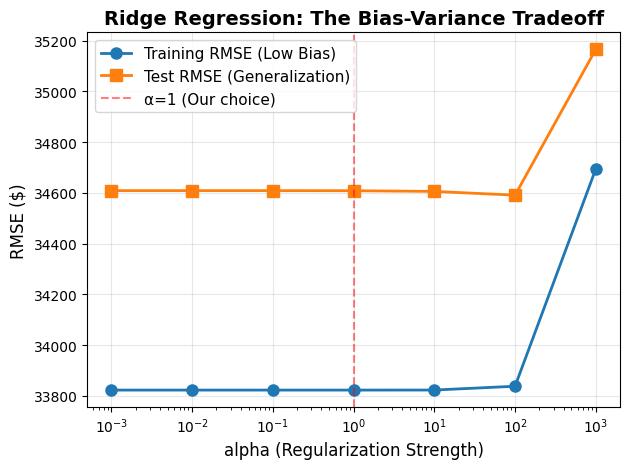

In [ ]:
# Create line plot showing the U-shaped bias-variance tradeoff for Ridge. Plot training RMSE and test RMSE on the y-axis, with alpha on the x-axis (log scale).
fig, ax = plt.subplots()

ax.plot(df_ridge_results["alpha"], df_ridge_results["RMSE_train"],
        marker="o", linewidth=2, markersize=8, label="Training RMSE (Low Bias)")

ax.plot(df_ridge_results["alpha"], df_ridge_results["RMSE_test"],
        marker="s", linewidth=2, markersize=8, label="Test RMSE (Generalization)")

ax.axvline(x=1, color='red', linestyle='--', alpha=0.5, label="α=1 (Our choice)")
ax.set_xlabel("alpha (Regularization Strength)", fontsize=12)
ax.set_ylabel("RMSE ($)", fontsize=12)
ax.set_xscale("log")
ax.set_title("Ridge Regression: The Bias-Variance Tradeoff", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The plot vividly illustrates the bias-variance tradeoff for Ridge Regression:

- Low alpha (left side of the graph): The Training RMSE is low, meaning the model fits the training data very well. However, the Test RMSE is higher, indicating the model is overfitting (high variance, low bias) and doesn't generalize well to new data.

- Optimal alpha (around alpha = 1, marked by the red dashed line): The Test RMSE reaches its minimum in this region, suggesting the best balance between bias and variance. The model generalizes optimally to unseen data.

- High alpha (right side of the graph): As alpha increases significantly, both Training RMSE and Test RMSE rise. This shows the model is underfitting (high bias, low variance), as it becomes too simplistic and fails to capture the underlying patterns in both training and test data.

> If train RMSE ≪ test RMSE → increase
 (reduce variance). If both are high and similar → decrease
 (reduce bias). The U-curve tells you which direction to move.

**Lasso: Feature Selection with Regularization**

Lasso behaves similarly to Ridge at extreme
 values, but the middle of the U-curve has a different character: at intermediate
 values, Lasso is simultaneously reducing overfitting and selecting features. The number of non-zero coefficients decreases monotonically as
 increases.

In [ ]:
# Create a Lasso tuning loop testing alphas [0.1, 1, 10, 100, 1000].
lasso_alphas = [0.1, 1, 10, 100, 1000]
lasso_results = []

for a in lasso_alphas:
  model = make_pipeline(
      OneHotEncoder(use_cat_names=True),
      StandardScaler(),
      Lasso(alpha=a, max_iter=10000)
  )

  model.fit(X_train, y_train)

  rmse_train = root_mean_squared_error(y_train, model.predict(X_train))
  rmse_test = root_mean_squared_error(y_test, model.predict(X_test))
  non_zero_features = (model.named_steps["lasso"].coef_ != 0).sum()

  lasso_results.append({
      "alpha": a,
      "RMSE_train": rmse_train,
      "RMSE_test": rmse_test,
      "Non_zero_features": non_zero_features
  })

df_lasso_results = pd.DataFrame(lasso_results)
print(df_lasso_results)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.369e+11, tolerance: 1.771e+09
  model = cd_fast.enet_coordinate_descent(


    alpha    RMSE_train     RMSE_test  Non_zero_features
0     0.1  33822.744751  34609.028375                 59
1     1.0  33822.747274  34608.744192                 58
2    10.0  33822.999559  34606.125222                 58
3   100.0  33842.884589  34604.362142                 55
4  1000.0  34402.388796  35093.094005                 29


From the df_lasso_results table, we can draw the following conclusions regarding Lasso regression and its hyperparameters:

- **Impact of Alpha on RMSE**: As the alpha value increases, the RMSE_train (Training RMSE) generally increases, while RMSE_test (Test RMSE) initially decreases and then starts to increase. This indicates a similar U-shaped bias-variance tradeoff as observed with Ridge regression, where an optimal alpha value balances underfitting and overfitting.
- **Feature Selection (Sparsity)**: A key characteristic of Lasso regression is its ability to perform feature selection by driving coefficients to zero. As alpha increases, the number of Non-zero Features decreases monotonically. For instance, at alpha = 0.1, there are 59 non-zero features, which reduces to 29 features at alpha = 1000. This demonstrates Lasso's effectiveness in simplifying the model by selecting only the most impactful features.
- **Optimal Alpha**: Looking at the RMSE_test column, the lowest test RMSE (34604.36) is achieved when alpha = 100. This suggests that alpha = 100 provides the best balance between model complexity and generalization performance among the tested values, leading to a more parsimonious model with 55 non-zero features.
- **Convergence Warning**: It's worth noting the ConvergenceWarning for alpha=1000. This suggests that for very high alpha values, the optimization algorithm might struggle to converge within the specified max_iter, or the model might be too constrained, leading to potential underfitting.

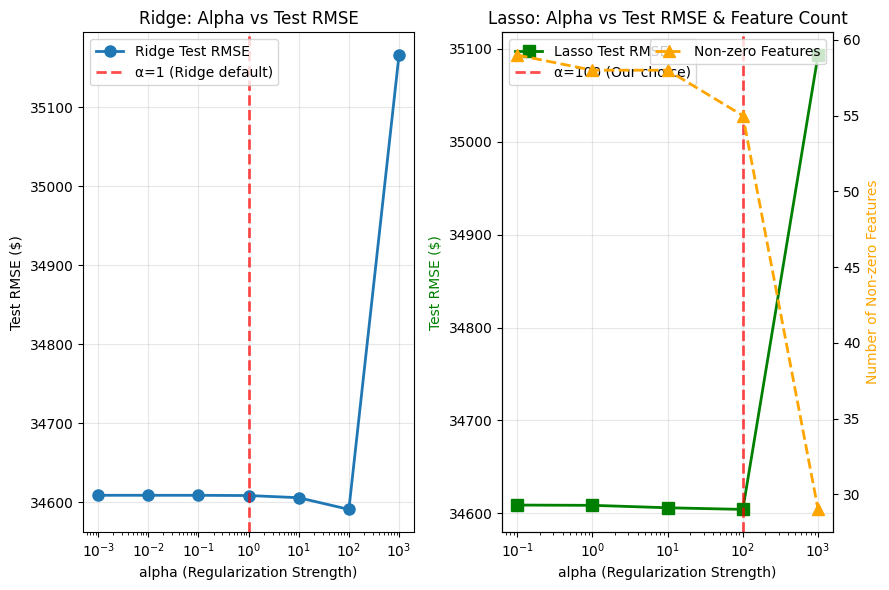

In [ ]:
# Compare Ridge and Lasso alpha selection visually.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6))

# Ridge comparison
ax1.plot(df_ridge_results["alpha"], df_ridge_results["RMSE_test"],
         marker='o', linewidth=2, markersize=8, label="Ridge Test RMSE")
ax1.axvline(x=1, color='red', linestyle='--', alpha=0.7, linewidth=2, label="α=1 (Ridge default)")
ax1.set_xlabel("alpha (Regularization Strength)")
ax1.set_ylabel("Test RMSE ($)")
ax1.set_xscale("log")
ax1.set_title("Ridge: Alpha vs Test RMSE")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Lasso comparison with feature count
ax2_twin = ax2.twinx()
ax2.plot(df_lasso_results["alpha"], df_lasso_results["RMSE_test"],
         marker='s', linewidth=2, markersize=8, color='green', label="Lasso Test RMSE")
ax2_twin.plot(df_lasso_results["alpha"], df_lasso_results["Non_zero_features"],
              marker='^', linewidth=2, markersize=8, color='orange', linestyle='--', label="Non-zero Features")
ax2.axvline(x=100, color='red', linestyle='--', alpha=0.7, linewidth=2, label="α=100 (Our choice)")
ax2.set_xlabel("alpha (Regularization Strength)")
ax2.set_ylabel("Test RMSE ($)", color='green')
ax2_twin.set_ylabel("Number of Non-zero Features", color='orange')
ax2.set_xscale("log")
ax2.set_title("Lasso: Alpha vs Test RMSE & Feature Count")
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **Why $\alpha = 100$ for Lasso?**
>
> From the tuning loop results, you can see distinct behavior across the range:
>
> - **Low $\alpha$ (0.1):** Lasso keeps most features active. Performance is good but the model may be retaining noise features. The model is closer to ordinary linear regression.
> - **$\alpha = 100$:** A good balance — aggressive enough to eliminate many noise features (sparse model) while keeping test RMSE reasonable. This is the "feature selection regime" where Lasso's unique strength is most visible.
> - **High $\alpha$ (1000):** Lasso has driven so many coefficients to zero that even useful features are being eliminated. Test RMSE rises — underfitting.
>
> $\alpha = 100$ is in the regime where Lasso performs meaningful feature selection without sacrificing too much predictive accuracy. However, the optimal $\alpha$ depends on your specific dataset — which is precisely why we use **LassoCV** to find it automatically.


**Automated Alpha Selection: RidgeCV and LassoCV**

Manually testing a grid of $\alpha$ values and eyeballing the U-curve is informative but not rigorous. **Cross-validation** provides a principled, statistically reliable method for selecting $\alpha$.

> **What is cross-validation?**
>
> Instead of a single train-test split, cross-validation divides the training data into $k$ folds (typically 5 or 10). For each candidate $\alpha$:
>
> 1. Train on $k-1$ folds, evaluate on the held-out fold
> 2. Repeat $k$ times (each fold takes a turn as the held-out set)
> 3. Average the $k$ error estimates
> 4. Select the $\alpha$ with the lowest average cross-validation error
>
> This approach uses all available training data for both training and validation, producing a more reliable estimate of generalization performance than a single split. A single train-test split estimate of performance has high variance — two different splits of the same data can yield quite different "optimal" alphas. Cross-validation averages out this variance by using all possible held-out folds.

In [ ]:
ridgeCV_model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    RidgeCV(alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000], cv=5)
)

ridgeCV_model.fit(X_train, y_train)

# Extract the optimal alpha:
optimal_ridge_alpha = ridgeCV_model.named_steps["ridgecv"].alpha_
print(f"RidgeCV selected alpha: {optimal_ridge_alpha}")
print(f"RidgeCV model test RMSE: {root_mean_squared_error(y_train, ridgeCV_model.predict(X_train)): .2f}")

lassoCV_model = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    LassoCV(alphas = [0.1, 1, 10, 100, 1000], cv=5, max_iter=10000)
)

lassoCV_model.fit(X_train, y_train)

# Extract the optimal alpha:
optimal_lasso_alpha = lassoCV_model.named_steps["lassocv"].alpha_
print(f"LassoCV selected alpha: {optimal_lasso_alpha}")
print(f"LassoCV model test RMSE: {root_mean_squared_error(y_train, lassoCV_model.predict(X_train)): .2f}")
print(f"Non-zero features (Lasso CV): {(lassoCV_model.named_steps['lassocv'].coef_ != 0).sum()}")

RidgeCV selected alpha: 100.0
RidgeCV model test RMSE:  33837.93
LassoCV selected alpha: 100.0
LassoCV model test RMSE:  33842.88
Non-zero features (Lasso CV): 55


**Visualizing and Interpreting Coefficients**:

The true power of Lasso's feature selection becomes visible when we examine the coefficients directly. Let's extract them and see which features the model kept and which it zeroed out.

In [ ]:
# Extract the coefficients and feature names from lasso_model. Create a Series named feat_imp_3.

# Extracting the coefficients from Lasso steps:
coefficients = lasso_model.named_steps["lasso"].coef_

# Extracting features names from OneHotEncoder step:
features = lasso_model.named_steps["onehotencoder"].get_feature_names_out()

# create series:
imp_features = pd.Series(coefficients, index=features)

print(f"Total features: {len(imp_features)}")
print(f"Non_zero features: {(imp_features != 0).sum()}")

Total features: 59
Non_zero features: 55


Plot the top 10 features by absolute coefficient value.

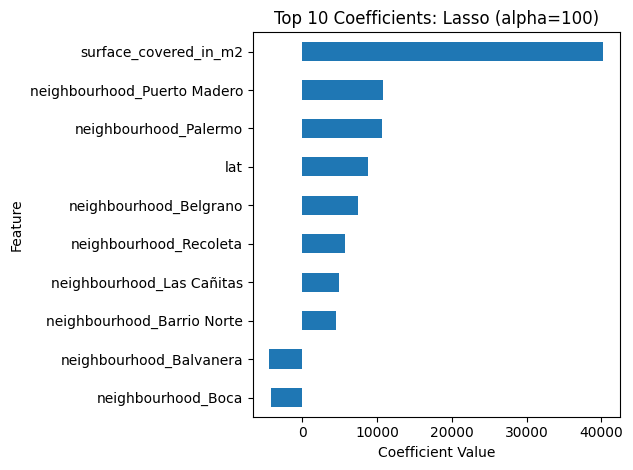

In [ ]:
fig,ax = plt.subplots()
imp_features.sort_values(key=abs).tail(10).plot(kind="barh", ax=ax)

ax.set_title("Top 10 Coefficients: Lasso (alpha=100)")
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
# Counting how many features have been exactly set to zero by L1 penalty:
lasso_zeros_count = (imp_features == 0).sum()

print(f"Lasso removed {lasso_zeros_count} features out of {len(imp_features)} total features.")
print(f"Percentage removed: {lasso_zeros_count/len(imp_features) * 100: .1f}")

Lasso removed 4 features out of 59 total features.
Percentage removed:  6.8


In [ ]:
assert 'lasso_zeros_count' in globals(), "❌ 'lasso_zeros_count' is not defined"
assert isinstance(lasso_zeros_count, (int, np.integer)), "❌ Should be an integer count"
assert lasso_zeros_count >= 0, "❌ Zero count should be non-negative"
assert lasso_zeros_count < len(imp_features), "❌ Should not eliminate all features"
assert lasso_zeros_count + (imp_features != 0).sum() == len(imp_features), "❌ Zero and non-zero counts should sum to total"
print("✓ All assertions passed")

✓ All assertions passed


In [ ]:
# Show top 5 positive and negative coefficients

print("="* 60)
print("TOP FIVE POSITIVE FEATURES (Increase Features)")
print("="* 60)

top_positive = imp_features.nlargest(5)
for feature, coef in top_positive.items():
  print(f"{feature:40} : ${coef:>10,.2f}")

print("=" * 60)
print("TOP FIVE NEGATIVE FEATURES (Decrease Features)")
print("=" * 60)

top_negative = imp_features.nsmallest(5)
for feature, coef in top_negative.items():
  print(f"{feature:40} : ${coef:>10,.2f}")

print("\n" + "=" * 60)
print("INTERPRETATION GUIDE")
print("=" * 60)
print("Remember: These coefficients are on STANDARDIZED features.")
print("A feature's importance depends on both its coefficient AND")
print("which other features Lasso eliminated. This is the 'feature selection'")
print("effect of Lasso in action.")

TOP FIVE POSITIVE FEATURES (Increase Features)
surface_covered_in_m2                    : $ 40,269.97
neighbourhood_Puerto Madero              : $ 10,825.76
neighbourhood_Palermo                    : $ 10,690.93
lat                                      : $  8,820.51
neighbourhood_Belgrano                   : $  7,381.63
TOP FIVE NEGATIVE FEATURES (Decrease Features)
neighbourhood_Balvanera                  : $ -4,412.69
neighbourhood_Boca                       : $ -4,169.05
neighbourhood_Once                       : $ -3,942.64
neighbourhood_Congreso                   : $ -2,748.89
neighbourhood_Villa Lugano               : $ -2,195.99

INTERPRETATION GUIDE
Remember: These coefficients are on STANDARDIZED features.
A feature's importance depends on both its coefficient AND
which other features Lasso eliminated. This is the 'feature selection'
effect of Lasso in action.


**Residual Analysis: Univariate vs. Multivariate:**

Adding neighborhood, latitude, and longitude to the model should capture more of the systematic price variation that size alone could not explain. Let's verify this by comparing residual patterns.

**Reading the residual plot for a multivariate model**:

With a single feature, we could plot residuals against that feature and directly see the pattern. With multiple features (surface area + lat + lon + 50+ neighborhood indicators), we plot residuals against the predicted values instead — the only single axis that summarizes all feature contributions.


The same interpretive rules apply:
- **Random scatter around zero:** All systematic variation is captured; remaining errors are unpredictable noise.
- **Funnel shape (heteroscedasticity):** Error variance increases with predicted price — a common pattern in financial data that linear models struggle to fully resolve.
- **Systematic curve:** The relationship is non-linear in ways the model's current features cannot capture.

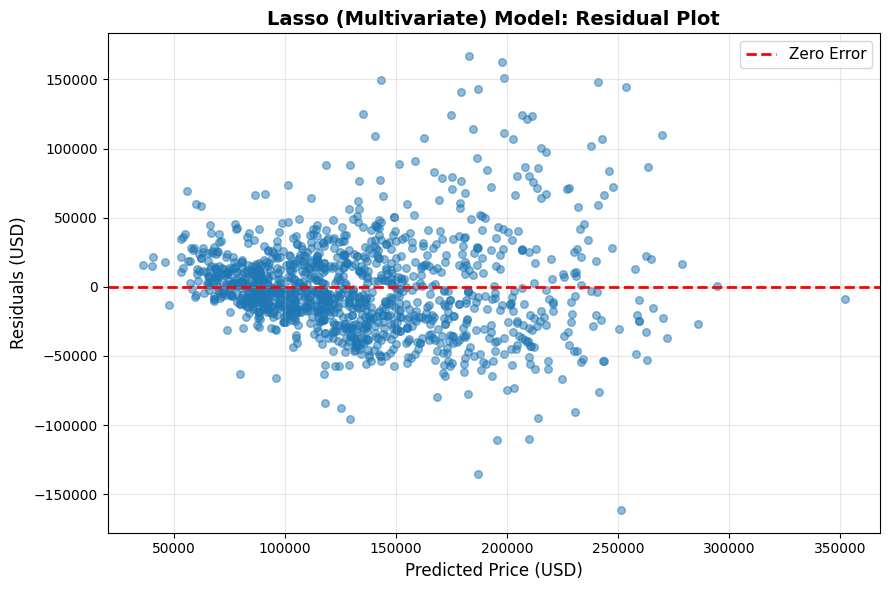

Mean of residuals: $-534.39 (should be close to 0)
Std of residuals: $34,614.08
Min residual: $-161,462.25
Max residual: $166,940.31


In [ ]:
# Create a residual plot for the multivariate Lasso model and compare it to the univariate model's residuals.
y_pred_lasso = lasso_model.predict(X_test)
lasso_residual = y_test - y_pred_lasso

# Create residual plot
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(y_pred_lasso, lasso_residual, alpha=0.5, s=30)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
ax.set_xlabel("Predicted Price (USD)", fontsize=12)
ax.set_ylabel("Residuals (USD)", fontsize=12)
ax.set_title("Lasso (Multivariate) Model: Residual Plot", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print(f"Mean of residuals: ${lasso_residual.mean():,.2f} (should be close to 0)")
print(f"Std of residuals: ${lasso_residual.std():,.2f}")
print(f"Min residual: ${lasso_residual.min():,.2f}")
print(f"Max residual: ${lasso_residual.max():,.2f}")

> **Comparing Univariate (Lesson 2) vs. Multivariate (Lesson 3) Residuals**
>
> **Univariate model (Lesson 2) — one feature: surface area**
> - Residuals showed systematic funnel-shaped heteroscedasticity — variance increased at higher prices
> - Systematic underestimation for some neighborhoods, overestimation for others
> - The model could not distinguish a 50m² apartment in Palermo from a 50m² apartment in a peripheral neighborhood
>
> **Multivariate model (Lesson 3) — surface area + coordinates + neighborhood**
> - Residuals should be more randomly scattered — less systematic structure
> - The model now differentiates apartments by location, not just size
> - The funnel shape may still be present (heteroscedasticity is a real property of price data) but should be less severe
>
> ❗️ **If the multivariate residuals still show systematic patterns**, it means important relationships remain uncaptured — non-linearities in the size-price relationship, interactions between neighborhood and size, or other factors our feature set does not include. Residual analysis is a diagnostic tool: it tells you what your current model is missing.